In [62]:
import cv2
import numpy as np
from skimage.morphology import skeletonize, dilation, square
from skimage import data
from matplotlib import pyplot as plt
import math

In [73]:
### SPOT IMAGES ARE 640x480 (WxH) ###


def color_segmentation(img, lower_color, upper_color):
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv_img, lower_color, upper_color)
    ribbon_segment = cv2.bitwise_and(img, img, mask=mask)
    return mask, ribbon_segment

def start(img):
    hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    lower_red1 = np.array([0, 120, 70])
    upper_red1 = np.array([10, 255, 255])
    mask_red1 = cv2.inRange(hsv_image, lower_red1, upper_red1)

    lower_red2 = np.array([170, 120, 70])
    upper_red2 = np.array([180, 255, 255])
    mask_red2 = cv2.inRange(hsv_image, lower_red2, upper_red2)

    mask_red = mask_red1 + mask_red2

    result_image = cv2.bitwise_and(img, img, mask=mask_red)

    img = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB).copy()
    # Convert mask_red to a format compatible with cvtColor
    plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
    plt.show()

    canny = cv2.Canny(result_image, 50, 200)
    dilated_canny = dilation(canny, square(3))
    plt.imshow(dilated_canny)
    plt.show()


    lines = cv2.HoughLinesP(dilated_canny, 1, np.pi / 180, 50, 3000, 10)
    x1max = 0
    x2max = 0 
    y1max = 0
    y2max = 0
    xmax = 0 
    ymax = 0 
    
    if lines is not None:
        for points in lines:
            x1, y1, x2, y2 = points[0]
            cv2.line(img, (x1, y1), (x2, y2), (255,255,255),7)
            height = []
            if (y1 < 1450) or (y2 < 1450):
                height.append(y1)
                height.append(y2)
            if x1 > x1max:
                x1max = x1
            if x2 > x2max:
                x2max = x2
            counter = 0
            for ypix in height:
                if counter < len(height):
                    if (ypix > height[counter]):
                        ymax = ypix
                        counter+=1



            if (x1max > x2max):
                xmax = x1max
            elif (x2max > x1max):
                xmax = x2max
            if (y1max > y2max):
                ymax = y1max
            elif (y2max > y1max):
                ymax = y2max
            
        print('(x2,y2)', xmax, ymax)
        plt.imshow(img)
        plt.show()

    # gray_img = cv2.cvtColor(result_image, cv2.COLOR_RGB2GRAY)
    # plt.imshow(gray_img, cmap='gray')
    # plt.show()
    
    # _, black_white = cv2.threshold(gray_img, 1, 255, cv2.THRESH_BINARY)
    
    # plt.title("Binary Image")
    # plt.imshow(black_white, cmap='gray')
    # plt.show()

    # # Normalize the image to range [0, 1] for skeletonization
    # black_white_norm = black_white // 255

    # skel_img = skeletonize(black_white_norm).astype(np.uint8)

    # dilated_skeleton = dilation(skel_img, square(3))

    # plt.title("Skeletonized Image")
    # plt.imshow(dilated_skeleton, cmap='gray')
    # plt.axis('off')
    # plt.show()


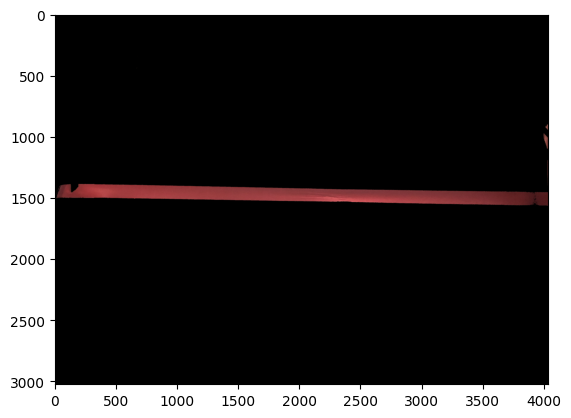

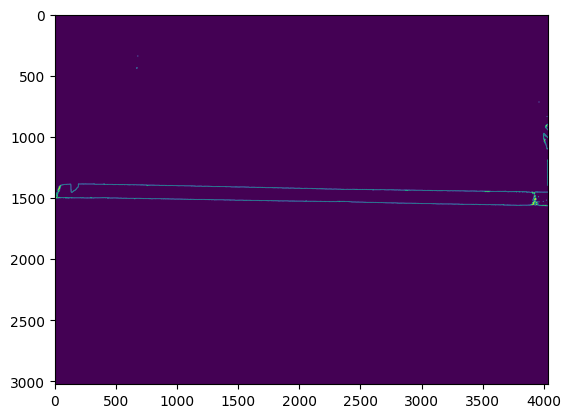

(x2,y2) 4031 1568


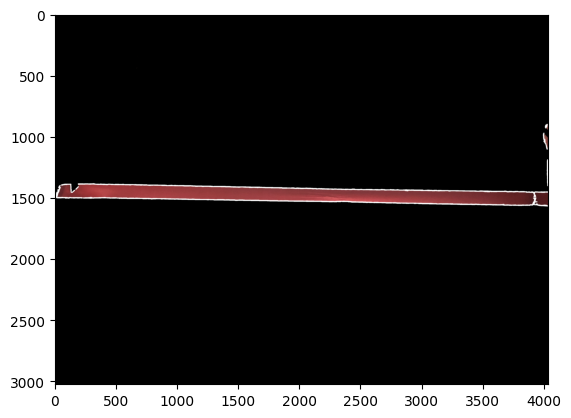

In [74]:
if __name__ == '__main__':
    # cap = cv2.VideoCapture(0)
    # while True:
    #     ret, img = cap.read()
    #     if not ret:
    #         print("Capture failed")
    #         break
    #     start(img)

    img = cv2.imread('/Users/sagar/Documents/GitHub/BDSpot/IMG_8428.JPG')
    if img is not None:
        start(img)
    else:
        print("Error: Image not found")

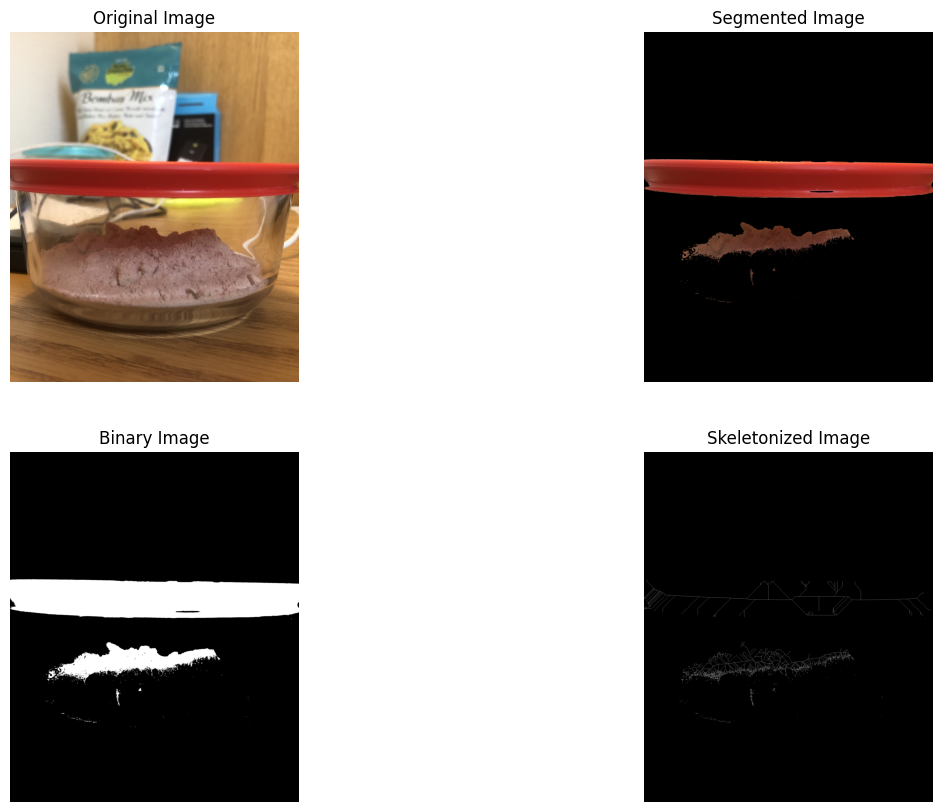

In [14]:
def color_segmentation(img, lower_color, upper_color):
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv_img, lower_color, upper_color)
    ribbon_segment = cv2.bitwise_and(img, img, mask=mask)
    return mask, ribbon_segment

def start(img):
    hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    lower_red1 = np.array([0, 120, 70])
    upper_red1 = np.array([10, 255, 255])
    mask_red1 = cv2.inRange(hsv_image, lower_red1, upper_red1)

    lower_red2 = np.array([170, 120, 70])
    upper_red2 = np.array([180, 255, 255])
    mask_red2 = cv2.inRange(hsv_image, lower_red2, upper_red2)

    mask_red = mask_red1 + mask_red2

    result_image = cv2.bitwise_and(img, img, mask=mask_red)

    # Convert mask_red to a format compatible with cvtColor
    plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
    plt.show()

    gray_img = cv2.cvtColor(result_image, cv2.COLOR_RGB2GRAY)
    plt.imshow(gray_img, cmap='gray')
    plt.show()
    
    _, black_white = cv2.threshold(gray_img, 1, 255, cv2.THRESH_BINARY)
    
    plt.title("Binary Image")
    plt.imshow(black_white, cmap='gray')
    plt.show()

    # Normalize the image to range [0, 1] for skeletonization
    black_white_norm = black_white // 255

    skel_img = skeletonize(black_white_norm).astype(np.uint8)

    dilated_skeleton = dilation(skel_img, square(3))

    plt.title("Skeletonized Image")
    plt.imshow(dilated_skeleton, cmap='gray')
    plt.axis('off')
    plt.show()
